In [10]:
import pandas as pd

df_clean = pd.read_csv("../data/processed/sephora_clean.csv")
df_clean.head()

/var/folders/bx/xxftvqk17n33yx6l437wb7200000gn/T/ipykernel_551/1326429665.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("../data/processed/sephora_clean.csv")


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,...,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,rating_category
0,21907641410,3.0,1.0,0.0,1.0,1.0,0.0,2023-02-25,nice consistency however im not sure its doing...,Not sure it’s doing what was promised,...,0,0,0,0,NaN,Skincare,Eye Care,Eye Creams & Treatments,0,neutral
1,5201105842,5.0,1.0,1.0,1.0,0.0,1.0,2023-02-16,i cannot express how much i love this eye crea...,Genuinely amazing,...,0,0,0,0,NaN,Skincare,Eye Care,Eye Creams & Treatments,0,positive
2,1878596139,5.0,1.0,1.0,2.0,0.0,2.0,2022-10-31,this depuffs super well does not help with dar...,Excellent de-puffer!,...,0,0,0,0,NaN,Skincare,Eye Care,Eye Creams & Treatments,0,positive
3,1949686936,4.0,1.0,1.0,2.0,0.0,2.0,2022-06-13,love it it keeps crows feet and fine lines awa...,NaN,...,0,0,0,0,NaN,Skincare,Eye Care,Eye Creams & Treatments,0,positive
4,5651999467,5.0,1.0,1.0,2.0,0.0,2.0,2022-06-11,im 46 and i can honestly say this has helped m...,really helps relax and blur the lines.,...,0,0,0,0,NaN,Skincare,Eye Care,Eye Creams & Treatments,0,positive


 1- RATING DISTRIBUTION

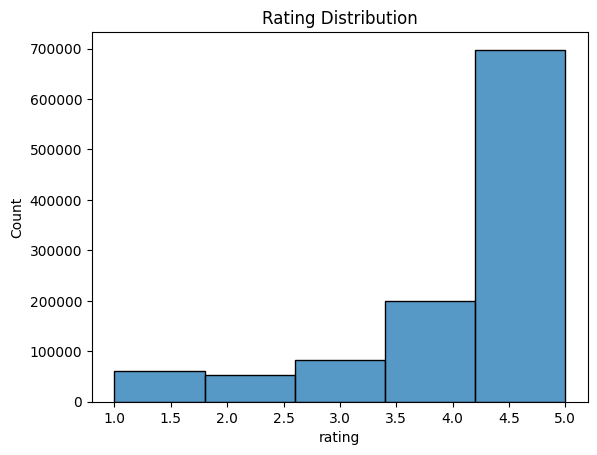

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean["rating"], bins=5)
plt.title("Rating Distribution")
plt.show()

📊 2) IS_RECOMMENDED ANALİZİ

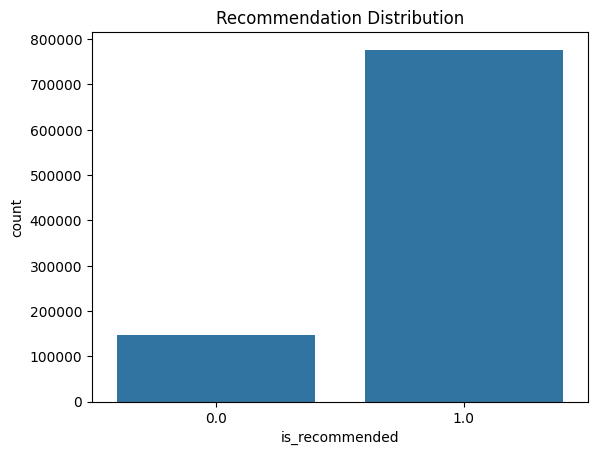

In [12]:
sns.countplot(x="is_recommended", data=df_clean)
plt.title("Recommendation Distribution")
plt.show()

📊 3) PRICE vs RATING

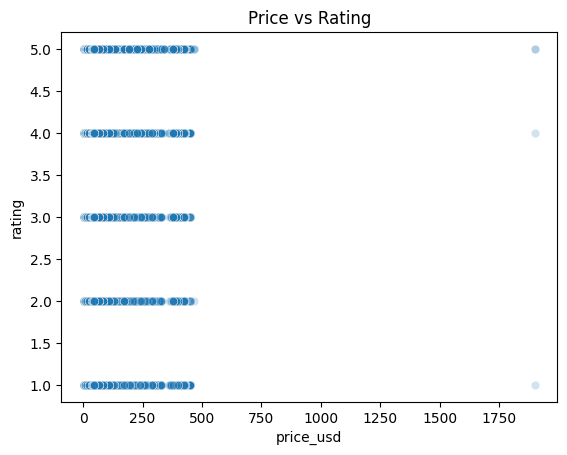

In [13]:
sns.scatterplot(x="price_usd", y="rating", data=df_clean, alpha=0.2)
plt.title("Price vs Rating")
plt.show()

4) CATEGORY ANALYSIS

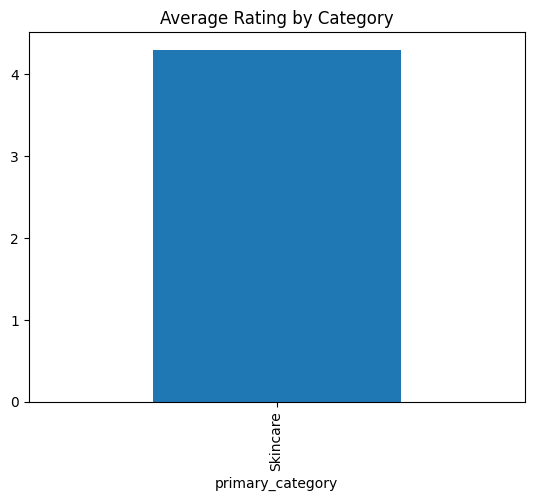

In [14]:
df_clean.groupby("primary_category")["rating"].mean().sort_values().plot(kind="bar")
plt.title("Average Rating by Category")
plt.show()

📊 5) TOP PRODUCTS

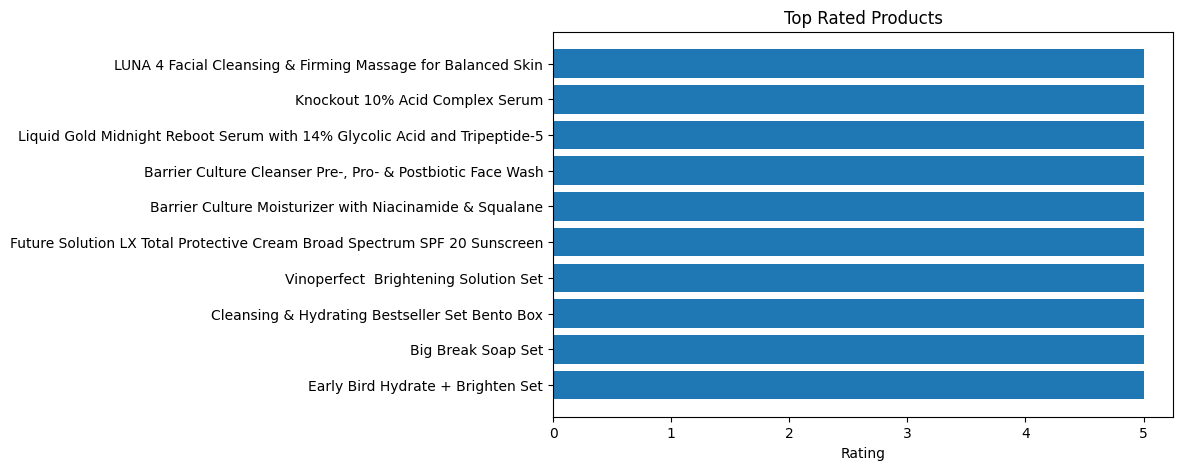

In [15]:
import matplotlib.pyplot as plt

top_products = (
    df_clean.groupby("product_name")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.barh(top_products["product_name"], top_products["rating"])
plt.title("Top Rated Products")
plt.xlabel("Rating")
plt.gca().invert_yaxis()
plt.show()

📊 8) MOST REVIEWED PRODUCTS

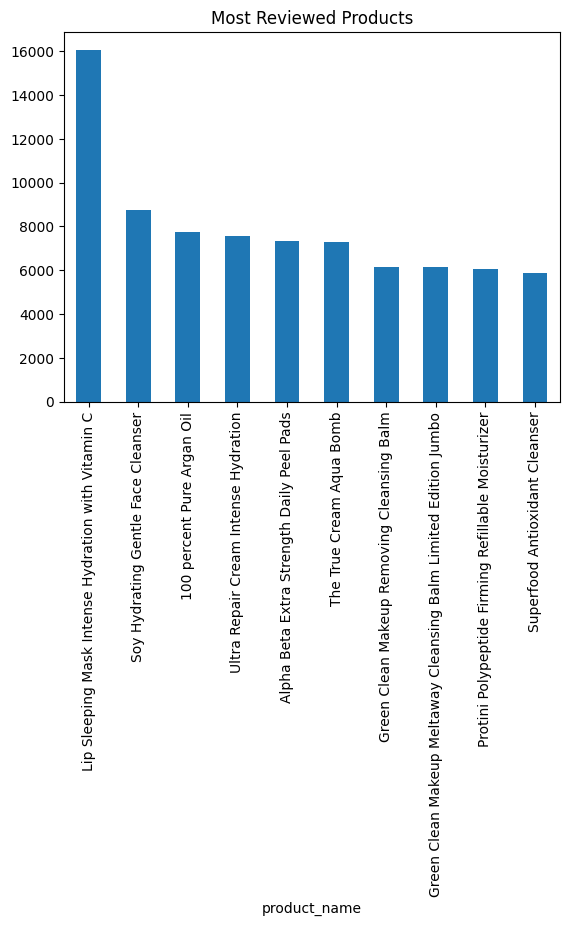

In [16]:
df_clean["product_name"].value_counts().head(10).plot(kind="bar")
plt.title("Most Reviewed Products")
plt.show()

In [17]:
#numeric kolonların seçilmesi
num_cols = df_clean.select_dtypes(include=["int64", "float64"])
num_cols.columns

Index(['rating', 'is_recommended', 'helpfulness', 'total_feedback_count',
       'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd',
       'brand_id', 'loves_count', 'reviews', 'limited_edition', 'new',
       'online_only', 'out_of_stock', 'sephora_exclusive', 'child_count'],
      dtype='object')

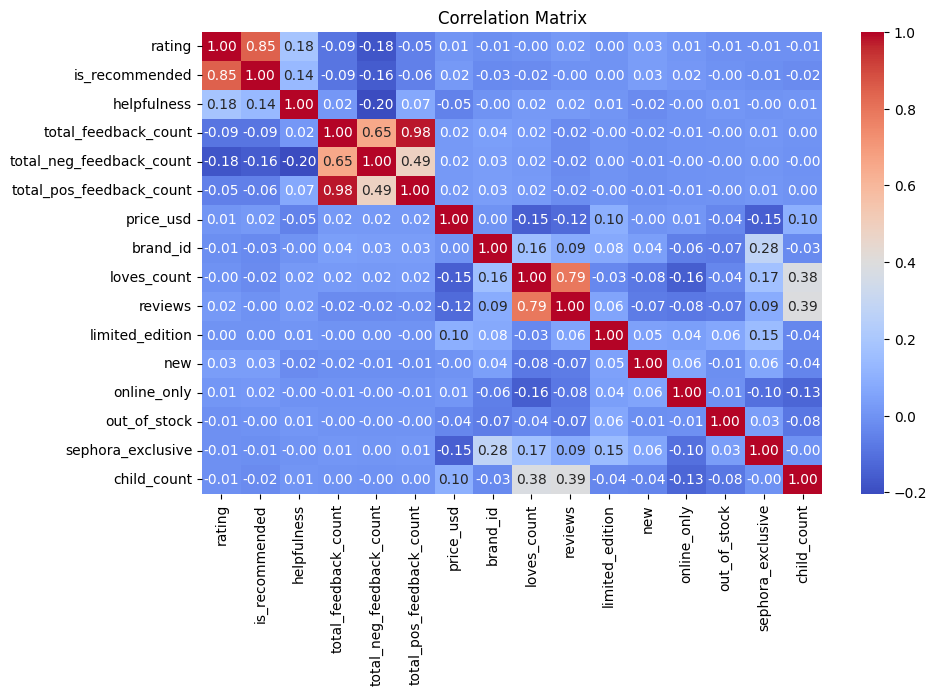

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = num_cols.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()